In [31]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt

In [5]:
iris = load_iris()

In [9]:
print("Shape:", iris.data.shape)
print("\nFeature names:", iris.feature_names)
print("\nClass names:", iris.target_names)

Shape: (150, 4)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Class names: ['setosa' 'versicolor' 'virginica']


In [15]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Showing some results before applying scaler:\n", X_train[:3])
print("\nShowing some results after applying scaler:\n", X_train_scaled[:3])

Showing some results before applying scaler:
 [[4.4 2.9 1.4 0.2]
 [4.9 2.5 4.5 1.7]
 [6.8 2.8 4.8 1.4]]

Showing some results after applying scaler:
 [[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]]


In [23]:
knn = KNeighborsClassifier(n_neighbors = 3)

knn.fit(X_train_scaled, y_train)
accuracy = knn.score(X_test_scaled, y_test)
print("acurracy:", accuracy)

acurracy: 0.9333333333333333


## Concluzie la aceasta cerinta
### Val. optima a lui k este in jur de un 3-5 deoarece ofera cel mai bun echilibru intre bias si varianta.
### Pentru un k mic modelul ajunge la un overfitting, iar pt. nu K mare pierde detalii importante (underfitting)

k=1 -> accuracy=0.967
k=2 -> accuracy=0.933
k=3 -> accuracy=0.933
k=4 -> accuracy=0.933
k=5 -> accuracy=0.933
k=6 -> accuracy=0.933
k=7 -> accuracy=0.967
k=8 -> accuracy=0.933
k=9 -> accuracy=0.967
k=10 -> accuracy=0.967
k=11 -> accuracy=0.967
k=12 -> accuracy=0.967
k=13 -> accuracy=0.967
k=14 -> accuracy=0.967
k=15 -> accuracy=0.967


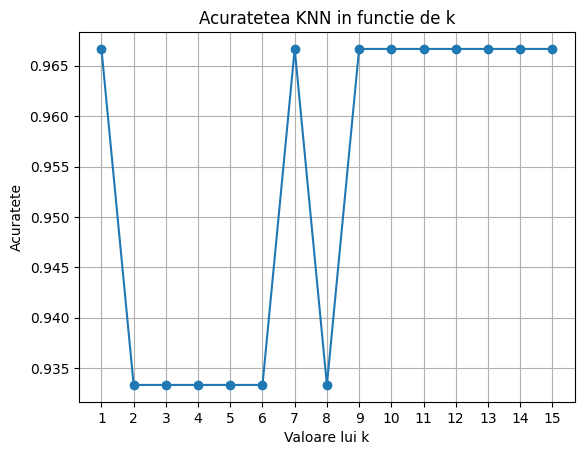

In [27]:
k_values = range(1, 16)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = knn.score(X_test_scaled, y_test)
    accuracies.append(acc)

for k, acc in zip(k_values, accuracies):
    print(f"k={k} -> accuracy={acc:.3f}")

plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Valoare lui k")
plt.ylabel("Acuratete")
plt.title("Acuratetea KNN in functie de k")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [30]:
y_pred = knn.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
print("Matrix confusion\n", cm)

Matrix confusion
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [33]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



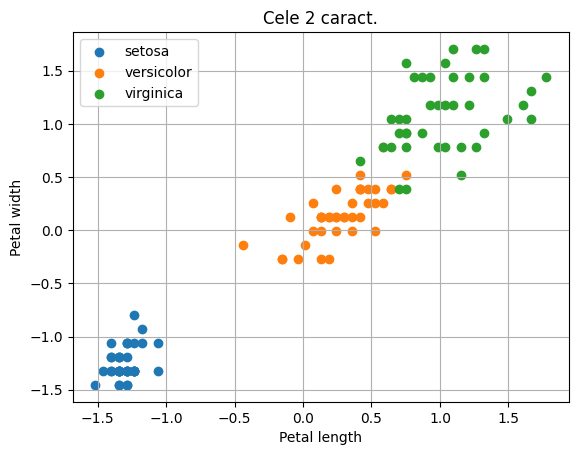

In [35]:
X_train_2D = X_train_scaled[:, 2:4]
X_test_2D  = X_test_scaled[:, 2:4]

plt.figure()

for i, label in enumerate(iris.target_names):
    plt.scatter(X_train_2D[y_train == i, 0], X_train_2D[y_train == i, 1], label=label)

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title("Cele 2 caract.")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
sepal_length = float(input("Sepal length (cm): "))
sepal_width  = float(input("Sepal width (cm): "))
petal_length = float(input("Petal length (cm): "))
petal_width  = float(input("Petal width (cm): "))

new_flower = [[sepal_length, sepal_width, petal_length, petal_width]]

new_flower_scaled = scaler.transform(new_flower)

prediction = knn.predict(new_flower_scaled)

print("Pred Flower:", iris.target_names[prediction][0])